In [38]:
import numpy as np
import h5py
import bacco
import matplotlib.pyplot as plt
import dask.array as dd

In [47]:
Nfiles = 32
base = "/cosmos_storage/data_sharing/tmp_resims/snapdir_000/"

# High-res particles
files = ["snapshot_ics_000.{:d}.hdf5".format(ifile) for ifile in range(32)]

dsets = [h5py.File(base+fn)['PartType3']['Coordinates'][()] for fn in files]
arrays = [dd.from_array(dset, chunks=(100000, 3)) for dset in dsets]
pos = dd.vstack(arrays)

# Low-res particles
files = ["bak-snapshot_ics_000.{:d}.hdf5".format(ifile) for ifile in range(32)]

dsets = [h5py.File(base+fn)['PartType1']['Coordinates'][()] for fn in files]
arrays = [dd.from_array(dset, chunks=(100000, 3)) for dset in dsets]
pos_low = dd.vstack(arrays)


Text(0, 0.5, '$y[$Mpc$/h]$')

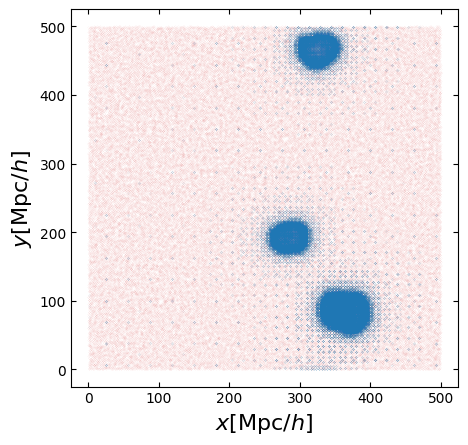

In [57]:
fig, ax = plt.subplots(dpi=100, figsize=(5,5))

ax.scatter(pos_low[::10000,0], pos_low[::10000,1], marker='.',s=0.001, color='C3', label='Particle-3')
ax.scatter(pos[:,0], pos[:,1], marker='.',s=0.001, color='C0', label='Particle-1')

ax.set_xlabel('$x[$Mpc$/h]$', fontsize=16)
ax.set_ylabel('$y[$Mpc$/h]$', fontsize=16)